# RAG 기초 - 문서 처리와 임베딩

#### 필요한 패키지 설치
`pip install pypdf`

In [1]:
import math

from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
EMBEDDING_MODEL_NAME = "gemini-embedding-2"


C:\Users\김나린\AppData\Local\Temp\ipykernel_23612\2912453539.py:4: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader, TextLoader


### RAG (Retrieval-Augmented Generation)

LLM은 학습 시점 이후의 정보나 비공개 문서를 알지 못하며, 알고 있는 것처럼 부정확한 내용을 생성할 수도 있다. 예를 들어 우리 회사의 사내 규정, 최신 제품 매뉴얼, 비공개 문서 등은 모델의 기존 학습 지식만으로 신뢰할 수 있게 답하기 어렵다.

**RAG**는 사용자의 질문과 관련된 문서를 먼저 **검색(Retrieval)** 한 뒤, 그 문서를 LLM의 프롬프트에 함께 넣어서 **응답을 생성(Generation)** 하는 방식이다. 모델을 다시 학습시키지 않고도 외부 문서를 답변의 근거로 활용할 수 있다. 다만 검색된 문서가 부정확하거나 질문과 맞지 않으면 답변 역시 부정확할 수 있다.

```
사용자 질문: "연차 신청은 어떻게 해?"

❌ LLM만 사용 → "일반적으로 HR 부서에 문의하세요..." (모호한 답변)
✅ RAG 사용  → 사내 규정 문서 검색 → "사내 포털 > 인사 > 연차 신청에서 가능합니다" (문서에 근거한 답변)
```

### RAG 파이프라인 전체 흐름

```
[ 인덱싱 단계 — 사용자 질문 전에 미리 수행 ]
문서 → 로드(DocumentLoader) → 분할(TextSplitter) → 임베딩 → 벡터 DB 저장

[ 질의 응답 단계 — 사용자 질문이 들어오면 수행 ]
질문 → 임베딩 → 벡터 DB 검색 → 관련 문서 추출 → LLM에 전달 → 응답 생성
```

### Document Loader

RAG에서 사용할 문서를 로드하는 도구이다. LangChain은 다양한 형식의 문서 로더를 제공한다.

| 로더 | 형식 | 패키지 |
|------|------|--------|
| `TextLoader` | `.txt` | `langchain_community` |
| `PyPDFLoader` | `.pdf` | `langchain_community` + `pypdf` |
| `CSVLoader` | `.csv` | `langchain_community` |
| `WebBaseLoader` | 웹페이지 | `langchain_community` |

여기서 사용하는 로더의 `load()` 메서드는 `Document` 객체의 리스트를 반환한다.

```python
# Document 구조
Document(
    page_content="문서의 텍스트 내용...",
    metadata={"source": "파일경로", "page": 0, ...}
)
```

`page_content`는 검색과 임베딩에 사용할 본문이고, `metadata`는 출처와 페이지 번호 같은 **부가 정보**를 담는 딕셔너리이다. 로더마다 자동으로 채우는 항목은 다르며, 이 정보는 나중에 "이 내용이 어디서 왔는지"를 추적할 때 사용한다.

로더마다 문서를 나누는 기준이 다르다. `TextLoader`는 파일 전체를 하나의 Document로 반환하고, `PyPDFLoader`는 페이지 단위로 나누어 반환한다. `PyPDFLoader`의 `page` metadata는 0부터 시작한다.

Document Loader가 파일의 구조를 항상 완벽하게 복원하는 것은 아니다. 이미지로만 구성된 스캔 PDF는 OCR이 필요할 수 있고, 표나 다단 편집 문서는 텍스트의 읽기 순서가 달라질 수 있다.

아래에서는 텍스트 파일과 PDF 파일을 로드하는 방법을 살펴본다.

### 텍스트 파일 로드

In [13]:
loader = TextLoader("data/sample_rules.txt", encoding="utf-8")
docs = loader.load()

print(f"문서 수: {len(docs)}")
print(f"metadata: {docs[0].metadata}")
print(f"내용 미리보기:\n{docs[0].page_content[:200]}")

문서 수: 1
metadata: {'source': 'data/sample_rules.txt'}
내용 미리보기:
회사 연차 규정

제1조 (목적)
이 규정은 주식회사 테크스타(이하 "회사")의 연차 유급휴가에 관한 사항을 정한다.

제2조 (연차 부여)
1. 1년간 80% 이상 출근한 직원에게 15일의 유급휴가를 부여한다.
2. 3년 이상 근속한 직원에게는 2년마다 1일의 가산 휴가를 부여한다.
3. 최대 연차일수는 25일로 한다.

제3조 (연차 신청)
1. 연차는


### PDF 파일 로드

`PyPDFLoader`는 PDF를 페이지 단위로 분리하여 각 페이지를 하나의 `Document`로 반환한다.

In [14]:
loader = PyPDFLoader("data/SPRi AI Brief_9월호_산업동향_0909_F.pdf")
docs = loader.load()

print(f"문서 수 (= 페이지 수): {len(docs)}")
for doc in docs[:3]:  # 처음 3페이지만 미리보기
    print(f"\n--- 페이지 {doc.metadata['page']} ---")
    print(doc.page_content[:200])

문서 수 (= 페이지 수): 28

--- 페이지 0 ---
2025년
9월호
인공지능 산업의 최신 동향

--- 페이지 1 ---
SPRi AI Brief 2025년 9월호
2
CONTENTS
정책･법제 ∙ 영국 과학혁신기술부, 영국 컴퓨트 로드맵 발표 2
∙ 중국 정부, 글로벌 거버넌스를 위한 세계 AI 협력기구 창설 제안 3
∙ 미국 연방법원, 오토파일럿 사망사건에서 테슬라의 책임 인정 4
∙ 미국 연방조달청, AI 플랫폼 ‘USAi’ 공개 및 주요 AI 기업과 제품 제공 계약 체

--- 페이지 2 ---
| 2025 년 9월호 |
정책･법제


### Text Splitter (텍스트 분할)

문서를 통째로 임베딩하면 두 가지 문제가 생긴다.

1. **검색 정확도 저하**: 긴 문서 안에 여러 주제가 섞여 있으면, 질문과 관련 없는 내용까지 포함된다
2. **입력 크기 제한**: 임베딩 모델과 LLM은 한 번에 처리할 수 있는 토큰 수에 제한이 있다

따라서 문서를 적절한 크기의 **청크(chunk)** 로 나눈 뒤 각 청크를 임베딩한다.

### 핵심 파라미터

| 파라미터 | 설명 | 예시 |
|---------|------|------|
| `chunk_size` | 청크의 최대 크기 (문자 수) | 500 |
| `chunk_overlap` | 인접 청크 간 겹치는 부분 | 50 |

```
원본: [ABCDEFGHIJ]

chunk_size=5, overlap=2:
  청크1: [ABCDE]
  청크2: [DEFGH]
  청크3: [GHIJ]
       ↑ overlap으로 문맥 단절 방지
```

`chunk_overlap`이 있으면 청크 경계에서 문맥이 끊기는 것을 줄일 수 있다.

### RecursiveCharacterTextSplitter

일반 텍스트 분할에 권장되는 범용 분할기이다. `\n\n`(빈 줄, 문단 경계) → `\n`(줄바꿈) → ` `(공백) 순서로 분할을 시도한다. 문단, 줄, 단어 경계를 우선 사용하고, 그래도 크면 더 작은 문자 단위로 나눈다.

In [15]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
)

chunks = splitter.split_documents(docs)

print(f"원본 문서 수: {len(docs)}")
print(f"분할 후 청크 수: {len(chunks)}")

for i, chunk in enumerate(chunks[8:12]):
    print(f"\n--- 청크 {i} (길이: {len(chunk.page_content)}, 페이지: {chunk.metadata.get('page')}) ---")
    print(chunk.page_content)

원본 문서 수: 28
분할 후 청크 수: 90

--- 청크 0 (길이: 474, 페이지: 4) ---
정책･법제 기업･산업 기술･연구 인력･교육
3
중국 정부, 글로벌 거버넌스를 위한 세계 AI 협력기구 창설 제안
n 중국의 리창 총리가 궁극적으로 인류에게 이익이 되는 AI를 위한 세계 각국의 공동 거버넌스를 
강조하며 세계 AI 협력 기구의 설립을 제안 
n 중국 정부는 AI 기회의 공동 포착과 혁신 발전, AI를 통한 산업 발전, 표준과 규범 합의, AI 역량 
강화를 위한 국제협력을 골자로 하는 ‘AI 글로벌 거버넌스 행동계획’도 발표
KEY Contents
£ 중국, 세계 AI 협력기구 설립 통해 AI 글로벌 거버넌스 주도 의지 피력
n 리창(李强) 중국 총리가 2025년 7월 26일 상하이에서 열린 2025년 세계AI대회(WAIC) 및 AI 글로벌 
거버넌스 고위급 회의 기조연설에서 세계 AI 협력기구 창설을 공식 제안 
∙ 리창 총리는 AI가 인류의 이익을 위한 공공재로서 더 많은 국가와 집단이 혜택을 누릴 수 있어야 한다며,

--- 청크 1 (길이: 469, 페이지: 4) ---
글로벌 사우스(Global South)* 를 중심으로 전 세계에 AI 개발 경험과 기술 제품을 공유하겠다고 강조
* 주로 남반구나 북반구의 저위도에 위치한 120여개 개발도상국을 지칭
∙ AI 기술의 돌파구를 마련하기 위한 협력에 더욱 집중하여 기초 과학기술 R&D 협력을 심화하고 기술과 
인재 교류를 강화하는 한편, 글로벌 거버넌스에 더욱 집중하기 위한 세계 AI 협력기구 설립을 제안
£ 세계 각국의 공동 참여를 촉구하는 ‘AI 글로벌 거버넌스 행동계획’ 발표  
n 중국 정부는 이번 행사에서 글로벌 AI 개발과 거버넌스에서 아래와 같은 조치를 통해 세계 각국의 
참여와 협력을 촉구하는 ‘AI 글로벌 거버넌스 행동계획’도 발표
∙ (AI 기회 공동 포착과 혁신 발전) 다양한 국제 과학기술 협력 플랫폼의 구축과 혁신 친화적 정책 환경 조성, 
정책과 규제 조율 강화, 

### 다른 청킹 방법론

`RecursiveCharacterTextSplitter` 외에도 문서 특성에 맞는 청킹 방법이 있다.

| 방법 | 기준 | 적합한 상황 |
|--------|------|------------|
| `RecursiveCharacterTextSplitter` | 문자 수 (빈 줄 → 줄바꿈 → 공백 → 문자 단위) | 문단·줄·단어 경계를 우선하는 범용 문서 |
| `TokenTextSplitter` | 토큰 수 | 임베딩 모델의 토큰 제한을 정확히 맞춰야 할 때 |
| `MarkdownHeaderTextSplitter` | 마크다운 헤더 (`#`, `##` 등) | 마크다운 문서. 섹션 구조를 유지하며 분할 |
| `HTMLHeaderTextSplitter` | HTML 헤더 (`h1`, `h2` 등) | 웹페이지 크롤링 결과 |
| `SemanticChunker` | 인접 문장의 임베딩 유사도 | 주제 전환을 기준으로 나누고 싶을 때. 문장 단위 임베딩이 필요해 계산량과 API 사용량이 증가할 수 있음 |
| Parent-Child Chunking | 작은 검색용 청크와 큰 전달용 청크를 연결 | 세밀한 검색과 넓은 문맥이 모두 필요할 때. 청크 간 매핑 관리가 필요 |

### 임베딩 (Embedding)

임베딩은 텍스트를 **숫자 벡터(리스트)** 로 변환하는 것이다. 의미가 비슷한 텍스트는 비슷한 벡터로 변환되므로, 벡터 간의 거리를 측정하면 텍스트의 의미적 유사도를 계산할 수 있다.

**개념 예시**

```
"고양이"  → [0.12, -0.34, 0.56, ...] ─┐
"강아지"  → [0.11, -0.31, 0.55, ...] ─┤ 가까움 (의미 유사)
"자동차"  → [-0.87, 0.42, -0.15, ...] ─ 멂 (의미 다름)
```

- 임베딩 벡터의 차원 수는 모델과 설정에 따라 다르다
- 벡터의 개별 숫자를 사람이 직접 해석하기는 어렵고, 임베딩은 의미의 정답이 아니라 모델이 학습한 방식으로 텍스트의 특징을 표현한 결과이다
- 중요한 것은 벡터 간의 **상대적 거리**이다
- 문서와 질문을 비교하려면 같은 임베딩 모델과 같은 차원 설정으로 변환해야 한다

`RecursiveCharacterTextSplitter`의 `chunk_size`는 기본적으로 문자 수를 기준으로 하지만, 임베딩 모델의 입력 제한은 토큰 수를 기준으로 하므로 청크가 모델의 최대 입력 크기를 넘지 않는지 확인해야 한다.

### Gemini Embedding API

LangChain의 임베딩 모델은 두 가지 메서드를 제공한다. 두 메서드는 모두 텍스트를 벡터로 변환하지만, 검색 질문과 저장할 문서라는 입력의 역할에 맞게 구분해 사용한다.

| 메서드 | 용도 | 입력 | 출력 |
|--------|------|------|------|
| `embed_query()` | 검색 질문을 임베딩 | 단일 문자열 | 벡터 하나 |
| `embed_documents()` | 저장할 문서를 임베딩 | 문자열 리스트 | 벡터 리스트 |

In [16]:
embeddings = GoogleGenerativeAIEmbeddings(model=EMBEDDING_MODEL_NAME)

# 단일 텍스트 임베딩
vector = embeddings.embed_query("고양이는 귀엽다")

print(f"벡터 차원: {len(vector)}")
print(f"처음 5개 값: {vector[:5]}")

벡터 차원: 3072
처음 5개 값: [-0.008659504, 0.004564434, 0.003567579, 0.012966436, 0.004280134]


In [17]:
# 여러 텍스트를 한 번에 임베딩
texts = [
    "고양이는 귀엽다",
    "강아지는 충성스럽다",
    "Python은 프로그래밍 언어다",
]

vectors = embeddings.embed_documents(texts)

for text, vec in zip(texts, vectors):
    print(f"\"{text}\" → 차원: {len(vec)}, 처음 3개: {vec[:3]}")

"고양이는 귀엽다" → 차원: 3072, 처음 3개: [-0.008659504, 0.004564434, 0.003567579]
"강아지는 충성스럽다" → 차원: 3072, 처음 3개: [0.00626025, 0.008142829, -0.0007131165]
"Python은 프로그래밍 언어다" → 차원: 3072, 처음 3개: [0.014867135, -0.009349661, 0.030119946]


### 코사인 유사도 (Cosine Similarity)

두 벡터가 얼마나 비슷한 방향을 가리키는지를 측정한다. 값의 범위는 -1 ~ 1이며, 1에 가까울수록 유사하다.

```
cosine_similarity(A, B) = (A · B) / (|A| × |B|)
```

- `A · B`: 두 벡터의 내적 (각 원소를 곱한 후 합산)
- `|A|`: 벡터 A의 크기 (각 원소의 제곱합의 제곱근)

2차원 벡터로 예를 들면 직관적으로 이해할 수 있다.

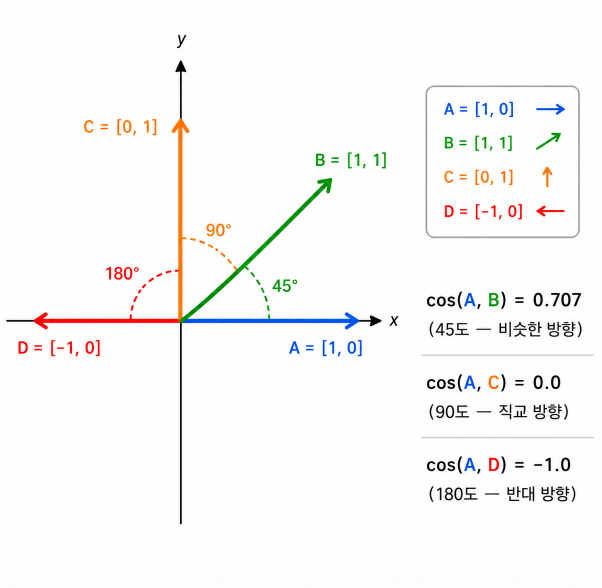

실제 임베딩은 수천 차원의 벡터이지만 계산 원리는 동일하다. 방향이 비슷하면 유사도가 높고, 다르면 낮다.

이 값은 벡터의 방향 관계를 나타내며, 자연어의 `같은 의미`, `무관한 의미`, `반대 의미`를 그대로 보장하지는 않는다. 또한 관련 여부를 나누는 보편적인 점수 기준은 없다. 점수 분포는 임베딩 모델과 데이터에 따라 다르므로 검색 결과를 비교하거나 평가 데이터로 기준을 정해야 한다.

벡터 간 거리를 측정하는 방법에는 코사인 유사도 외에도 유클리드 거리(L2), 내적(Inner Product) 등이 있다. 텍스트 임베딩 검색에서는 코사인 유사도가 흔히 사용되지만, 거리 함수는 임베딩 모델과 벡터 저장소의 설정에 맞춰야 한다.

In [18]:
def cosine_similarity(vec1: list[float], vec2: list[float]) -> float:
    """차원이 같은 두 벡터의 코사인 유사도를 계산한다."""
    if len(vec1) != len(vec2):
        raise ValueError("두 벡터의 차원이 같아야 합니다.")

    dot_product = sum(a * b for a, b in zip(vec1, vec2))
    magnitude1 = math.sqrt(sum(a ** 2 for a in vec1))
    magnitude2 = math.sqrt(sum(b ** 2 for b in vec2))
    if magnitude1 == 0 or magnitude2 == 0:
        raise ValueError("0 벡터의 코사인 유사도는 계산할 수 없습니다.")

    return dot_product / (magnitude1 * magnitude2)

In [19]:
sentences = [
    "고양이가 소파에서 낮잠을 잔다",
    "고양이가 침대에서 자고 있다",
    "강아지가 공원에서 뛰어놀고 있다",
    "주식 시장이 급락했다",
]

vectors = embeddings.embed_documents(sentences)

# 첫 번째 문장과 나머지 문장의 유사도 비교
base = sentences[0]
print(f"기준: \"{base}\"\n")

for i in range(1, len(sentences)):
    sim = cosine_similarity(vectors[0], vectors[i])
    print(f"  vs \"{sentences[i]}\"")
    print(f"  → 유사도: {sim:.4f}\n")

기준: "고양이가 소파에서 낮잠을 잔다"

  vs "고양이가 침대에서 자고 있다"
  → 유사도: 0.7754

  vs "강아지가 공원에서 뛰어놀고 있다"
  → 유사도: 0.4716

  vs "주식 시장이 급락했다"
  → 유사도: 0.4775



### 임베딩 기반 유사도 검색

아래 예제는 사내 규정 문서를 임베딩한 뒤, 질문 벡터를 모든 문서 벡터와 직접 비교하여 코사인 유사도가 높은 문서 2개를 반환한다. 질문과 문서에 서로 다른 표현이 사용되어도 의미가 유사하면 찾을 수 있으며, 순위와 점수의 차이도 함께 확인할 수 있다.

In [12]:
documents = [
    "연차 신청은 그룹웨어의 근태 관리 메뉴에서 제출합니다.",
    "재택근무를 하려면 근무일 3일 전까지 팀장의 승인을 받아야 합니다.",
    "법인카드 사용 후 영수증은 경비 처리 시스템에 등록해야 합니다.",
    "사내 계정의 비밀번호는 보안 포털에서 재설정할 수 있습니다.",
    "회의실은 사내 예약 시스템에서 최대 2시간까지 예약할 수 있습니다.",
    "주차 등록은 총무팀에 차량 번호를 제출하여 신청합니다.",
]

document_vectors = embeddings.embed_documents(documents)

queries = [
    "휴가를 쓰려면 어디에서 신청하나요?",
    "집에서 일하려면 어떤 절차가 필요한가요?",
    "회사 카드로 결제한 뒤 무엇을 해야 하나요?",
]

for query in queries:
    query_vector = embeddings.embed_query(query)

    scores = []
    for document, document_vector in zip(documents, document_vectors):
        similarity = cosine_similarity(query_vector, document_vector)
        scores.append((similarity, document))

    scores.sort(key=lambda item: item[0], reverse=True)
    print(f'질문: "{query}"')
    for rank, (score, document) in enumerate(scores[:2], start=1):
        print(f"  {rank}. [{score:.4f}] {document}")
    print()

질문: "휴가를 쓰려면 어디에서 신청하나요?"
  1. [0.7226] 연차 신청은 그룹웨어의 근태 관리 메뉴에서 제출합니다.
  2. [0.6569] 재택근무를 하려면 근무일 3일 전까지 팀장의 승인을 받아야 합니다.

질문: "집에서 일하려면 어떤 절차가 필요한가요?"
  1. [0.6815] 재택근무를 하려면 근무일 3일 전까지 팀장의 승인을 받아야 합니다.
  2. [0.5223] 법인카드 사용 후 영수증은 경비 처리 시스템에 등록해야 합니다.

질문: "회사 카드로 결제한 뒤 무엇을 해야 하나요?"
  1. [0.8041] 법인카드 사용 후 영수증은 경비 처리 시스템에 등록해야 합니다.
  2. [0.5984] 사내 계정의 비밀번호는 보안 포털에서 재설정할 수 있습니다.

